# EDA — Duolingo Spaced Repetition Dataset

Источник: Settles & Meeder, "A Trainable Spaced Repetition Model for Language Learning" (ACL 2016).
12.8M строк, каждая — попытка вспомнить конкретное слово (lexeme) конкретным пользователем.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/settles.acl16.learning_traces.13m.csv"


Matplotlib is building the font cache; this may take a moment.


## Сэмпл для итераций

Полный датасет — 12.8M строк / ~1.3GB. Для быстрых итераций берём сэмпл по `user_id`, чтобы не резать историю попыток внутри пользователя.

In [2]:
df_full_users = pd.read_csv(DATA_PATH, usecols=["user_id"])
unique_users = df_full_users["user_id"].unique()
print(f"всего пользователей: {len(unique_users)}")

rng = np.random.default_rng(42)
sample_users = set(rng.choice(unique_users, size=min(20000, len(unique_users)), replace=False))
del df_full_users


всего пользователей: 115222


In [3]:
chunks = pd.read_csv(DATA_PATH, chunksize=500_000)
sample_chunks = [chunk[chunk["user_id"].isin(sample_users)] for chunk in chunks]
df = pd.concat(sample_chunks, ignore_index=True)
df.to_csv("../data/sample.csv", index=False)
df.shape


(2252756, 12)

## Быстрая загрузка сэмпла (со второго запуска)

In [4]:
df = pd.read_csv("../data/sample.csv")
df.head()


,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct
0,1.0,1362076081,27649635,u:FO,de,en,76390c1350a8dac31186187e2fe1e178,lernt/lernen<vblex><pri><p3><sg>,6,4,2,2
1,0.5,1362076081,27649635,u:FO,de,en,7dfd7086f3671685e2cf1c1da72796d7,die/die<det><def><f><sg><nom>,4,4,2,1
2,1.0,1362076081,27649635,u:FO,de,en,35a54c25a2cda8127343f6a82e6f6b7d,mann/mann<n><m><sg><nom>,5,4,1,1
3,0.5,1362076081,27649635,u:FO,de,en,0cf63ffe3dda158bc3dbd55682b355ae,frau/frau<n><f><sg><nom>,6,5,2,1
4,1.0,1362076081,27649635,u:FO,de,en,84920990d78044db53c1b012f5bf9ab5,das/das<det><def><nt><sg><nom>,4,4,1,1


In [5]:
df.describe(include="all")


,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct
count,2.252756e+06,2.252756e+06,2.252756e+06,2252756,2252756,2252756,2252756,2252756,2.252756e+06,2.252756e+06,2.252756e+06,2.252756e+06
unique,NaN,NaN,NaN,20000,6,4,13796,13490,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,u:h2_R,en,en,827a8ecb89f9b59ac5c29b620a5d3ed6,a/a<det><ind><sg>,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,5326,858081,1394675,21402,21402,NaN,NaN,NaN,NaN
mean,8.981042e-01,1.362588e+09,7.232873e+05,NaN,NaN,NaN,NaN,NaN,1.897310e+01,1.707259e+01,1.818070e+00,1.647246e+00
std,2.687855e-01,2.926100e+05,2.230205e+06,NaN,NaN,NaN,NaN,NaN,6.638913e+01,5.734122e+01,1.360241e+00,1.318147e+00
min,0.000000e+00,1.362076e+09,1.000000e+00,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+00,1.362342e+09,5.100000e+02,NaN,NaN,NaN,NaN,NaN,3.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.362590e+09,7.440750e+04,NaN,NaN,NaN,NaN,NaN,7.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.362841e+09,4.396170e+05,NaN,NaN,NaN,NaN,NaN,1.500000e+01,1.400000e+01,2.000000e+00,2.000000e+00


In [6]:
df.isna().sum()


p_recall             0
timestamp            0
delta                0
user_id              0
learning_language    0
ui_language          0
lexeme_id            0
lexeme_string        0
history_seen         0
history_correct      0
session_seen         0
session_correct      0
dtype: int64

## Распределение p_recall и delta

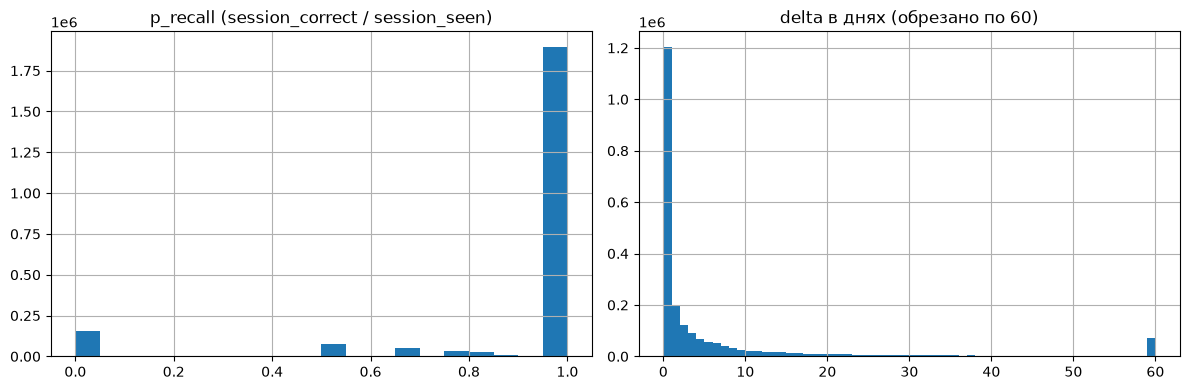

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["p_recall"].hist(bins=20, ax=axes[0])
axes[0].set_title("p_recall (session_correct / session_seen)")

(df["delta"] / 86400).clip(upper=60).hist(bins=60, ax=axes[1])
axes[1].set_title("delta \u0432 \u0434\u043d\u044f\u0445 (\u043e\u0431\u0440\u0435\u0437\u0430\u043d\u043e \u043f\u043e 60)")
plt.tight_layout()


## Целевая переменная для Half-Life Regression

По методике Settles & Meeder: наблюдаемый "период полураспада" памяти
`hl = -delta_days / log2(p_recall)`, ограниченный снизу и сверху для
устойчивости (в оригинале — [15 мин, 274 дня]).

In [8]:
MIN_HALF_LIFE = 15.0 / (24 * 60)  # 15 минут в днях
MAX_HALF_LIFE = 274.0             # дней

p = df["p_recall"].clip(lower=0.0001, upper=0.9999)
delta_days = df["delta"] / 86400
df["half_life"] = (-delta_days / np.log2(p)).clip(lower=MIN_HALF_LIFE, upper=MAX_HALF_LIFE)
df["half_life"].describe()


count    2.252756e+06
mean     1.560899e+02
std      1.240033e+02
min      1.041667e-02
25%      1.925313e+01
50%      2.740000e+02
75%      2.740000e+02
max      2.740000e+02
Name: half_life, dtype: float64

## Дальше

- Feature engineering: `history_seen`, `history_correct`, лексема/язык как категориальные признаки
- Baseline SM-2 для сравнения
- Обучение Half-Life Regression, метрика MAE по `p_recall`